In [6]:
import pystac_client
import xarray as xr
import esgvoc.api as ev


A newer version of esgvoc is available!
  Current version: 2.2.2
  Latest version:  5.2.0

Update using one of:
  pip install --upgrade esgvoc
  uv pip install --upgrade esgvoc
  conda update esgvoc

After updating, reinstall vocabularies with:
  esgvoc install



### Search using ESGF East Index 

In [7]:
stac_endpoint = "https://discovery.east.esgf.io"

In [8]:
clnt = pystac_client.Client.open(stac_endpoint)

### Check top-levels collections for CMIP6 present

In [9]:
collection_name = None

for coll in clnt.get_collections():
    print(f"{coll.id}: {coll.description}")
    if coll.id.upper() == "CMIP6":
        collection_name = coll.id

print(f"Using collection: {collection_name}") 

CMIP6: CMIP6 (Coupled Model Intercomparison Project Phase 6) is an international framework that coordinates global climate model simulations. It is used to understand past, present, and future climate changes and to support climate research and assessments such as IPCC reports.
CMIP6Plus: Data Reference Syntax (DRS) specifications for the Coupled Model Intercomparison Project Phase 6 Plus (CMIP6Plus)
CMIP7: Data Reference Syntax (DRS) specifications for the Coupled Model Intercomparison Project Phase 7 (CMIP7)
CORDEX-CMIP6: Data Reference Syntax (DRS) specifications for Coordinated Regional Climate Downscaling Experiment (CORDEX) based on the Coupled Model Intercomparison Project Phase 6 (CMIP6)
obs4REF: Data Reference Syntax (DRS) specifications for the obs4REF project
Using collection: CMIP6


### Search based on ScenarioMIP which has been indexed with Virtualizarr references

In [48]:
print(f"Searching in collection: {collection_name}")
item_search = clnt.search(
    collections=["CMIP6"],
    query=[
        #"cmip6:activity_id=ScenarioMIP",
        "cmip6:institution_id=MOHC",
        #"cmip6:variant_label=r1i1p1f1",
        #"cmip6:frequency=day",
        "cmip6:variable_id=tas"
    ],
    max_items=200,
)
print(f"Number of items found: {item_search.matched()}")

Searching in collection: CMIP6
Number of items found: 12158


In [43]:
items = list(item_search.items())

### Pick the first search hit, extract the Kerchunk reference if available, otherwise select a netCDF file. Load in xarray

In [ ]:
file_ref = None

for item in items:
    if "reference_file" in item.assets:
        # Check for a Kerchunk reference file asset
        file_ref = item.assets["reference_file"]
        print(f"Found Kerchunk reference file: {file_ref.href}")
        break

if file_ref is not None:
    # Kerchunk reference file found, extract the open_zarr_kwargs and href
    zarr_kwargs = file_ref.to_dict()["open_zarr_kwargs"]
    file_uri = file_ref.href
else:  
    file_uri = items[0].assets[next(iter(items[0].assets))].href

print(f"Using file URI: {file_uri}")


Using file URI: https://dap.ceda.ac.uk/badc/cmip6/data/CMIP6/HighResMIP/MOHC/HadGEM3-GC31-MM/spinup-1950/r1i1p1f1/day/tas/gn/v20171030/tas_day_HadGEM3-GC31-MM_spinup-1950_r1i1p1f1_gn_19500101-19501230.nc


In [58]:
if file_ref is not None:
    kwargs = {
        "engine": "kerchunk",
        "open_dataset_options": {"chunks": {}}
    }
else:
    kwargs = {
        "engine": "h5netcdf"
    }

print(f"Opening dataset with kwargs: {kwargs}")
print(file_uri)
ds = xr.open_dataset(file_uri, **kwargs)


Opening dataset with kwargs: {'engine': 'h5netcdf'}
https://dap.ceda.ac.uk/badc/cmip6/data/CMIP6/HighResMIP/MOHC/HadGEM3-GC31-MM/spinup-1950/r1i1p1f1/day/tas/gn/v20171030/tas_day_HadGEM3-GC31-MM_spinup-1950_r1i1p1f1_gn_19500101-19501230.nc


In [59]:
ds

<xarray.Dataset> Size: 202MB
Dimensions:    (time: 360, bnds: 2, lat: 324, lon: 432)
Coordinates:
  * time       (time) object 3kB 1950-01-01 12:00:00 ... 1950-12-30 12:00:00
  * lat        (lat) float64 3kB -89.72 -89.17 -88.61 ... 88.61 89.17 89.72
  * lon        (lon) float64 3kB 0.4167 1.25 2.083 2.917 ... 357.9 358.7 359.6
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 6kB ...
    lat_bnds   (lat, bnds) float64 5kB ...
    lon_bnds   (lon, bnds) float64 7kB ...
    tas        (time, lat, lon) float32 202MB ...
Attributes: (12/42)
    Conventions:             CF-1.7 CMIP-6.0
    activity_id:             HighResMIP
    branch_method:           no parent
    contact:                 enquiries@metoffice.gov.uk
    creation_date:           2017-10-25T20:27:43Z
    experiment:              coupled spinup with fixed 1950s forcings from 19...
    ...                      ...
    variant_label:           r1i1p1f1
    license:                 CMIP6 model data produced by MOHC is licensed un...
    cmor_version:            3.2.4
    further_info_url:        https://furtherinfo.es-doc.org/CMIP6.MOHC.HadGEM...
    data_specs_version:      01.00.23
    history:                 2017-10-25T20:26:40Z MIP Convert v2.0.3.dev0+r14...

### Plot first time step

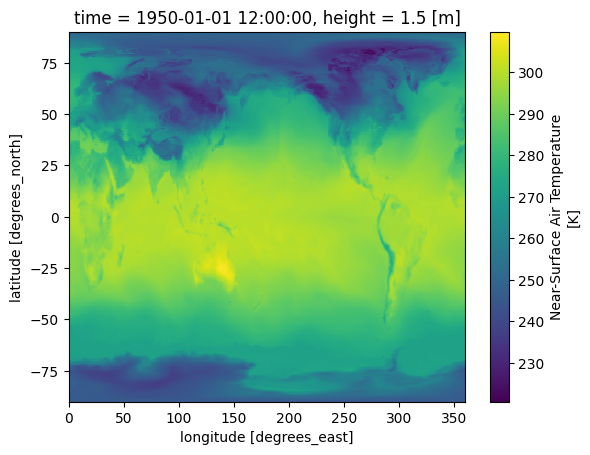

In [56]:
#ds.sel(time='2015-01').isel(time=0).tas.plot()
ds.isel(time=0).tas.plot()

In [ ]:
xr.show_versions()


INSTALLED VERSIONS
------------------
commit: None
python: 3.14.2 (main, Dec  5 2025, 16:49:16) [Clang 17.0.0 (clang-1700.6.3.2)]
python-bits: 64
OS: Darwin
OS-release: 25.3.0
machine: arm64
processor: arm
byteorder: little
LC_ALL: None
LANG: C.UTF-8
LOCALE: ('C', 'UTF-8')
libhdf5: 1.14.6
libnetcdf: 4.9.3

xarray: 2026.2.0
pandas: 3.0.1
numpy: 2.4.2
scipy: None
netCDF4: 1.7.4
pydap: None
h5netcdf: None
h5py: None
zarr: 3.1.5
cftime: 1.6.5
nc_time_axis: None
iris: None
bottleneck: None
dask: 2026.1.2
distributed: None
matplotlib: 3.10.8
cartopy: None
seaborn: None
numbagg: None
fsspec: 2026.2.0
cupy: None
pint: None
sparse: None
flox: None
numpy_groupies: None
setuptools: 82.0.0
pip: 25.3
conda: None
pytest: None
mypy: None
IPython: 9.11.0
sphinx: None
